# Biblioteca Database

- COLAB, PYTHON
- CREAZIONE DEL DATABASE CON *SQLITE* DI 100 LIBRI
- OPERAZIONI ELEMENTARI: SELECT,UPDATE,DELETE,JOIN
- TABELLA HASH
- B-TREE
- CONFRONTO METODI


In [1]:
import sqlite3
import random
import string
import pandas as pd

In [2]:
libri_reali = [
("Il Signore degli Anelli","J.R.R. Tolkien","Fantasy"),
("Lo Hobbit","J.R.R. Tolkien","Fantasy"),
("1984","George Orwell","SciFi"),
("La fattoria degli animali","George Orwell","Romanzo"),
("Dune","Frank Herbert","SciFi"),
("Neuromante","William Gibson","SciFi"),
("Fahrenheit 451","Ray Bradbury","SciFi"),
("Fondazione","Isaac Asimov","SciFi"),
("Il Nome della Rosa","Umberto Eco","Storico"),
("I Promessi Sposi","Alessandro Manzoni","Romanzo"),
("Il Conte di Montecristo","Alexandre Dumas","Romanzo"),
("I Tre Moschettieri","Alexandre Dumas","Romanzo"),
("Orgoglio e Pregiudizio","Jane Austen","Romanzo"),
("Emma","Jane Austen","Romanzo"),
("Moby Dick","Herman Melville","Romanzo"),
("Il Vecchio e il Mare","Ernest Hemingway","Romanzo"),
("Per chi suona la campana","Ernest Hemingway","Romanzo"),
("Il Grande Gatsby","F. Scott Fitzgerald","Romanzo"),
("Ulisse","James Joyce","Romanzo"),
("Dracula","Bram Stoker","Horror"),
("Frankenstein","Mary Shelley","Horror"),
("Il ritratto di Dorian Gray","Oscar Wilde","Romanzo"),
("Delitto e castigo","Fëdor Dostoevskij","Romanzo"),
("I fratelli Karamazov","Fëdor Dostoevskij","Romanzo"),
("Guerra e pace","Lev Tolstoj","Storico"),
("Anna Karenina","Lev Tolstoj","Romanzo"),
("Don Chisciotte","Miguel de Cervantes","Romanzo"),
("Il piccolo principe","Antoine de Saint-Exupéry","Romanzo"),
("Il processo","Franz Kafka","Romanzo"),
("Il castello","Franz Kafka","Romanzo"),
("La metamorfosi","Franz Kafka","Romanzo"),
("Lolita","Vladimir Nabokov","Romanzo"),
("Il maestro e Margherita","Michail Bulgakov","Romanzo"),
("Il deserto dei Tartari","Dino Buzzati","Romanzo"),
("Se questo è un uomo","Primo Levi","Storico"),
("Il barone rampante","Italo Calvino","Romanzo"),
("Il visconte dimezzato","Italo Calvino","Romanzo"),
("Le città invisibili","Italo Calvino","Romanzo"),
("Il sentiero dei nidi di ragno","Italo Calvino","Romanzo"),
("Il Gattopardo","Giuseppe Tomasi di Lampedusa","Storico"),
("Il fu Mattia Pascal","Luigi Pirandello","Romanzo"),
("Uno, nessuno e centomila","Luigi Pirandello","Romanzo"),
("Il giorno della civetta","Leonardo Sciascia","Romanzo"),
("Cristo si è fermato a Eboli","Carlo Levi","Romanzo"),
("La coscienza di Zeno","Italo Svevo","Romanzo"),
("Il codice Da Vinci","Dan Brown","Thriller"),
("Angeli e demoni","Dan Brown","Thriller"),
("Jurassic Park","Michael Crichton","SciFi"),
("The Andromeda Strain","Michael Crichton","SciFi"),
("The Shining","Stephen King","Horror"),
("It","Stephen King","Horror"),
("Misery","Stephen King","Horror"),
("Carrie","Stephen King","Horror"),
("Pet Sematary","Stephen King","Horror"),
("American Gods","Neil Gaiman","Fantasy"),
("Good Omens","Neil Gaiman","Fantasy"),
("Neverwhere","Neil Gaiman","Fantasy"),
("Snow Crash","Neal Stephenson","SciFi"),
("Cryptonomicon","Neal Stephenson","SciFi"),
("Ready Player One","Ernest Cline","SciFi"),
("The Martian","Andy Weir","SciFi"),
("Project Hail Mary","Andy Weir","SciFi"),
("Hyperion","Dan Simmons","SciFi"),
("Ender's Game","Orson Scott Card","SciFi"),
("The Road","Cormac McCarthy","Romanzo"),
("Blood Meridian","Cormac McCarthy","Romanzo"),
("No Country for Old Men","Cormac McCarthy","Romanzo"),
("The Catcher in the Rye","J.D. Salinger","Romanzo"),
("To Kill a Mockingbird","Harper Lee","Romanzo"),
("Lord of the Flies","William Golding","Romanzo"),
("The Stand","Stephen King","Horror"),
("The Dark Tower","Stephen King","Fantasy"),
("A Game of Thrones","George R.R. Martin","Fantasy"),
("A Clash of Kings","George R.R. Martin","Fantasy"),
("A Storm of Swords","George R.R. Martin","Fantasy"),
("The Hunger Games","Suzanne Collins","SciFi"),
("Catching Fire","Suzanne Collins","SciFi"),
("Mockingjay","Suzanne Collins","SciFi"),
("The Handmaid's Tale","Margaret Atwood","SciFi"),
("Oryx and Crake","Margaret Atwood","SciFi"),
("Brave New World","Aldous Huxley","SciFi"),
("Island","Aldous Huxley","SciFi"),
("The Time Machine","H.G. Wells","SciFi"),
("The War of the Worlds","H.G. Wells","SciFi"),
("The Invisible Man","H.G. Wells","SciFi"),
("The Hobbit Annotated","Douglas Anderson","Fantasy"),
("The Silmarillion","J.R.R. Tolkien","Fantasy"),
("Children of Hurin","J.R.R. Tolkien","Fantasy"),
("The Fall of Gondolin","J.R.R. Tolkien","Fantasy"),
("The Name of the Wind","Patrick Rothfuss","Fantasy"),
("The Wise Man's Fear","Patrick Rothfuss","Fantasy"),
("Mistborn","Brandon Sanderson","Fantasy"),
("The Way of Kings","Brandon Sanderson","Fantasy"),
("Words of Radiance","Brandon Sanderson","Fantasy"),
("Oathbringer","Brandon Sanderson","Fantasy")
]

In [5]:
# CONNECT DATABASE
conn = sqlite3.connect('biblioteca.db')
cursor = conn.cursor()

In [7]:
# CREATE TABLES

cursor.execute('''
CREATE TABLE IF NOT EXISTS autore(
 id_autore INTEGER PRIMARY KEY,
 nome TEXT,
 eta INTEGER
)
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS scaffale(
 id_scaffale INTEGER PRIMARY KEY,
 zona TEXT,
 piano INTEGER
)
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS libro(
 id_libro INTEGER PRIMARY KEY,
 titolo TEXT,
 genere TEXT,
 costo REAL,
 id_scaffale INTEGER,
 FOREIGN KEY(id_scaffale) REFERENCES scaffale(id_scaffale)
)
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS autore_libro(
 id_autore INTEGER,
 id_libro INTEGER,
 PRIMARY KEY(id_autore,id_libro),
 FOREIGN KEY(id_autore) REFERENCES autore(id_autore),
 FOREIGN KEY(id_libro) REFERENCES libro(id_libro)
)
''')

conn.commit()

In [8]:
# CONFIG


for titolo, autore, genere in libri_reali:

    cursor.execute(
        "INSERT INTO autore(nome) VALUES (?)",
        (autore,)
    )

    id_autore = cursor.lastrowid

    cursor.execute(
        "INSERT INTO libro(titolo, genere) VALUES (?,?)",
        (titolo, genere)
    )

    id_libro = cursor.lastrowid

    cursor.execute(
        "INSERT INTO autore_libro VALUES (?,?)",
        (id_autore, id_libro)
    )

conn.commit()

In [9]:
# CREATE INDEX (HASH LIKE)
cursor.execute('CREATE INDEX IF NOT EXISTS idx_autore ON autore(id_autore)')
cursor.execute('CREATE INDEX IF NOT EXISTS idx_libro ON libro(id_libro)')
cursor.execute('CREATE INDEX IF NOT EXISTS idx_scaffale ON scaffale(id_scaffale)')
cursor.execute('CREATE INDEX IF NOT EXISTS idx_al_autore ON autore_libro(id_autore)')
cursor.execute('CREATE INDEX IF NOT EXISTS idx_al_libro ON autore_libro(id_libro)')

conn.commit()

In [10]:
# VIEW TABLES
print(pd.read_sql_query('SELECT * FROM autore LIMIT 10',conn))
print(pd.read_sql_query('SELECT * FROM libro LIMIT 10',conn))
print(pd.read_sql_query('SELECT * FROM autore_libro LIMIT 10',conn))

   id_autore                nome   eta
0          1      J.R.R. Tolkien  None
1          2      J.R.R. Tolkien  None
2          3       George Orwell  None
3          4       George Orwell  None
4          5       Frank Herbert  None
5          6      William Gibson  None
6          7        Ray Bradbury  None
7          8        Isaac Asimov  None
8          9         Umberto Eco  None
9         10  Alessandro Manzoni  None
   id_libro                     titolo   genere costo id_scaffale
0         1    Il Signore degli Anelli  Fantasy  None        None
1         2                  Lo Hobbit  Fantasy  None        None
2         3                       1984    SciFi  None        None
3         4  La fattoria degli animali  Romanzo  None        None
4         5                       Dune    SciFi  None        None
5         6                 Neuromante    SciFi  None        None
6         7             Fahrenheit 451    SciFi  None        None
7         8                 Fondazione    S

In [27]:
import pandas as pd

print(pd.read_sql_query(
"SELECT id_libro,titolo,id_scaffale FROM libro LIMIT 10",
conn))

   id_libro                     titolo id_scaffale
0         1    Il Signore degli Anelli        None
1         2                  Lo Hobbit        None
2         3                       1984        None
3         4  La fattoria degli animali        None
4         5                       Dune        None
5         6                 Neuromante        None
6         7             Fahrenheit 451        None
7         8                 Fondazione        None
8         9         Il Nome della Rosa        None
9        10           I Promessi Sposi        None


In [28]:
def assegna_id_scaffale(conn):

    cursor = conn.cursor()
    cursor.execute("""
    UPDATE libro
    SET id_scaffale = id_libro
    """)
    conn.commit()
    print("ID scaffale assegnati")

In [29]:
assegna_id_scaffale(conn)
print(pd.read_sql_query('SELECT * FROM libro LIMIT 10',conn))

ID scaffale assegnati
   id_libro                     titolo   genere costo  id_scaffale
0         1    Il Signore degli Anelli  Fantasy  None            1
1         2                  Lo Hobbit  Fantasy  None            2
2         3                       1984    SciFi  None            3
3         4  La fattoria degli animali  Romanzo  None            4
4         5                       Dune    SciFi  None            5
5         6                 Neuromante    SciFi  None            6
6         7             Fahrenheit 451    SciFi  None            7
7         8                 Fondazione    SciFi  None            8
8         9         Il Nome della Rosa  Storico  None            9
9        10           I Promessi Sposi  Romanzo  None           10


In [30]:
#SELECT
cursor.execute("""
SELECT id_libro, titolo, genere
FROM libro
LIMIT 10
""")

print(cursor.fetchall())

[(1, 'Il Signore degli Anelli', 'Fantasy'), (2, 'Lo Hobbit', 'Fantasy'), (3, '1984', 'SciFi'), (4, 'La fattoria degli animali', 'Romanzo'), (5, 'Dune', 'SciFi'), (6, 'Neuromante', 'SciFi'), (7, 'Fahrenheit 451', 'SciFi'), (8, 'Fondazione', 'SciFi'), (9, 'Il Nome della Rosa', 'Storico'), (10, 'I Promessi Sposi', 'Romanzo')]


In [31]:
#UPLOAD
cursor.execute("""
INSERT INTO libro(titolo, genere, id_scaffale)
VALUES (?,?,?)
""", ("Il Silmarillion","Fantasy",101))

conn.commit()

In [33]:
#SERCH
import difflib

import difflib
import pandas as pd

def cerca_libro_fuzzy(conn, query):

    cursor = conn.cursor()

    # prendi tutti i titoli
    cursor.execute("SELECT titolo FROM libro")
    titoli = [row[0] for row in cursor.fetchall()]

    # trova titoli simili
    matches = difflib.get_close_matches(query, titoli, n=5, cutoff=0.5)

    if not matches:
        return "Nessun libro trovato"

    # query completa con JOIN
    query_sql = """
    SELECT
        libro.id_libro,
        libro.titolo,
        autore.nome AS autore,
        libro.genere,
        libro.id_scaffale
    FROM libro
    JOIN autore_libro
        ON libro.id_libro = autore_libro.id_libro
    JOIN autore
        ON autore.id_autore = autore_libro.id_autore
    WHERE libro.titolo = ?
    """

    risultati = []

    for titolo in matches:
        cursor.execute(query_sql,(titolo,))
        risultati.extend(cursor.fetchall())

    df = pd.DataFrame(
        risultati,
        columns=["id_libro","titolo","autore","genere","id_scaffale"]
    )

    return df

In [37]:
print(cerca_libro_fuzzy(conn,"Simarillion"))

   id_libro            titolo          autore   genere  id_scaffale
0        87  The Silmarillion  J.R.R. Tolkien  Fantasy           87


In [39]:
#DELETE
cursor.execute("""
DELETE FROM libro
WHERE id_libro = ?
""",(87,))

conn.commit()

In [40]:
print(cerca_libro_fuzzy(conn,"Simarillion"))

Empty DataFrame
Columns: [id_libro, titolo, autore, genere, id_scaffale]
Index: []


In [42]:
#JOIN (libro + autore + scaffale)
cursor.execute("""
SELECT
libro.id_libro,
libro.titolo,
autore.nome AS autore,
libro.genere,
libro.id_scaffale
FROM libro
JOIN autore_libro
ON libro.id_libro = autore_libro.id_libro
JOIN autore
ON autore.id_autore = autore_libro.id_autore
LIMIT 10
""")

print(cursor.fetchall())

[(1, 'Il Signore degli Anelli', 'J.R.R. Tolkien', 'Fantasy', 1), (2, 'Lo Hobbit', 'J.R.R. Tolkien', 'Fantasy', 2), (3, '1984', 'George Orwell', 'SciFi', 3), (4, 'La fattoria degli animali', 'George Orwell', 'Romanzo', 4), (5, 'Dune', 'Frank Herbert', 'SciFi', 5), (6, 'Neuromante', 'William Gibson', 'SciFi', 6), (7, 'Fahrenheit 451', 'Ray Bradbury', 'SciFi', 7), (8, 'Fondazione', 'Isaac Asimov', 'SciFi', 8), (9, 'Il Nome della Rosa', 'Umberto Eco', 'Storico', 9), (10, 'I Promessi Sposi', 'Alessandro Manzoni', 'Romanzo', 10)]


## Esempio HASH TABLE ASCII
Costruiamo un indice hash Python sui libri, divisi per Bucket.  Ogniuno di qquesti bucket contiene 10 elementi


In [72]:
# ASCII HASH TABLE
hash_index={}

cursor.execute('SELECT id_libro,titolo FROM libro')
for row in cursor.fetchall():
    key=row[0]
    bucket=key%10
    hash_index.setdefault(bucket,[]).append(row)

print("HASH TABLE")
for bucket in hash_index:
    print(f'Bucket {bucket} -> {hash_index[bucket][:10]}')

HASH TABLE
Bucket 1 -> [(1, 'Il Signore degli Anelli'), (11, 'Il Conte di Montecristo'), (21, 'Frankenstein'), (31, 'La metamorfosi'), (41, 'Il fu Mattia Pascal'), (51, 'It'), (61, 'The Martian'), (71, 'The Stand'), (81, 'Brave New World'), (91, "The Wise Man's Fear")]
Bucket 2 -> [(2, 'Lo Hobbit'), (12, 'I Tre Moschettieri'), (22, 'Il ritratto di Dorian Gray'), (32, 'Lolita'), (42, 'Uno, nessuno e centomila'), (52, 'Misery'), (62, 'Project Hail Mary'), (72, 'The Dark Tower'), (82, 'Island'), (92, 'Mistborn')]
Bucket 3 -> [(3, '1984'), (13, 'Orgoglio e Pregiudizio'), (23, 'Delitto e castigo'), (33, 'Il maestro e Margherita'), (43, 'Il giorno della civetta'), (53, 'Carrie'), (63, 'Hyperion'), (73, 'A Game of Thrones'), (83, 'The Time Machine'), (93, 'The Way of Kings')]
Bucket 4 -> [(4, 'La fattoria degli animali'), (14, 'Emma'), (24, 'I fratelli Karamazov'), (34, 'Il deserto dei Tartari'), (44, 'Cristo si è fermato a Eboli'), (54, 'Pet Sematary'), (64, "Ender's Game"), (74, 'A Clash of

In [76]:
def search_hash(book_id):

    bucket = book_id % 10
    passi = 0

    if bucket not in hash_index:
        return None, passi

    for row in hash_index[bucket]:

        passi += 1

        if row[0] == book_id:
            return row, passi

    return None, passi

In [77]:
result, steps = search_hash(30)

print("RISULTATO:", result)
print("PASSAGGI HASH:", steps)

RISULTATO: (30, 'Il castello')
PASSAGGI HASH: 3


## Esempio B-tree
Quando cerchi id_libro = 120 , Il sistema fa log₂(n) passaggi. Se hai 1.000.000 libri servono solo circa 20 confronti.

In [78]:
def show_tree(index):

    mid = len(index)//2

    left = index[:mid]
    root = index[mid]
    right = index[mid+1:]

    print("        ", root)
    print("   ", left)
    print("   ", right)

show_tree(btree_index)

         (48, 'Jurassic Park')
    [(1, 'Il Signore degli Anelli'), (2, 'Lo Hobbit'), (3, '1984'), (4, 'La fattoria degli animali'), (5, 'Dune'), (6, 'Neuromante'), (7, 'Fahrenheit 451'), (8, 'Fondazione'), (9, 'Il Nome della Rosa'), (10, 'I Promessi Sposi'), (11, 'Il Conte di Montecristo'), (12, 'I Tre Moschettieri'), (13, 'Orgoglio e Pregiudizio'), (14, 'Emma'), (15, 'Moby Dick'), (16, 'Il Vecchio e il Mare'), (17, 'Per chi suona la campana'), (18, 'Il Grande Gatsby'), (19, 'Ulisse'), (20, 'Dracula'), (21, 'Frankenstein'), (22, 'Il ritratto di Dorian Gray'), (23, 'Delitto e castigo'), (24, 'I fratelli Karamazov'), (25, 'Guerra e pace'), (26, 'Anna Karenina'), (27, 'Don Chisciotte'), (28, 'Il piccolo principe'), (29, 'Il processo'), (30, 'Il castello'), (31, 'La metamorfosi'), (32, 'Lolita'), (33, 'Il maestro e Margherita'), (34, 'Il deserto dei Tartari'), (35, 'Se questo è un uomo'), (36, 'Il barone rampante'), (37, 'Il visconte dimezzato'), (38, 'Le città invisibili'), (39, 'Il sent

In [80]:
import sqlite3
import networkx as nx
import matplotlib.pyplot as plt


def visualizza_bst(conn, target):

    cursor = conn.cursor()

    # =============================
    # CARICA LIBRI
    # =============================

    cursor.execute("SELECT id_libro FROM libro")
    ids = sorted([row[0] for row in cursor.fetchall()])


    # =============================
    # NODO ALBERO
    # =============================

    class Node:

        def __init__(self, value):
            self.value = value
            self.left = None
            self.right = None


    # =============================
    # COSTRUISCI ALBERO BILANCIATO
    # =============================

    def build_tree(values):

        if not values:
            return None

        mid = len(values) // 2

        node = Node(values[mid])

        node.left = build_tree(values[:mid])
        node.right = build_tree(values[mid+1:])

        return node


    root = build_tree(ids)


    # =============================
    # CERCA ELEMENTO
    # =============================

    path = []

    def search(node):

        if node is None:
            return False

        path.append(node.value)

        if node.value == target:
            return True

        if target < node.value:
            return search(node.left)
        else:
            return search(node.right)


    search(root)

    print("Percorso ricerca:", path)
    print("Passaggi ricerca:", len(path) - 1)


    # =============================
    # COSTRUISCI GRAFO
    # =============================

    G = nx.DiGraph()

    def add_edges(node):

        if node is None:
            return

        if node.left:
            G.add_edge(node.value, node.left.value)
            add_edges(node.left)

        if node.right:
            G.add_edge(node.value, node.right.value)
            add_edges(node.right)


    add_edges(root)


    # =============================
    # LAYOUT GERARCHICO
    # =============================

    def hierarchy_pos(G, root, width=1., vert_gap=0.15, vert_loc=0, xcenter=0.5):

        pos = {root: (xcenter, vert_loc)}

        children = list(G.successors(root))

        if children:

            dx = width / len(children)
            nextx = xcenter - width / 2 - dx / 2

            for child in children:

                nextx += dx

                pos.update(
                    hierarchy_pos(
                        G,
                        child,
                        width=dx,
                        vert_gap=vert_gap,
                        vert_loc=vert_loc - vert_gap,
                        xcenter=nextx
                    )
                )

        return pos


    pos = hierarchy_pos(G, root.value)


    # =============================
    # COLORI NODI
    # =============================

    node_colors = []

    for node in G.nodes():

        if node == root.value:
            node_colors.append("green")

        elif node in path:
            node_colors.append("red")

        else:
            node_colors.append("lightblue")


    # =============================
    # DISEGNO
    # =============================

    plt.figure(figsize=(12,8))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=1500,
        node_color=node_colors,
        arrows=False
    )

    plt.title("Binary Search Tree - Percorso di ricerca")
    plt.show()

Percorso ricerca: [48, 24, 36, 30]
Passaggi ricerca: 3


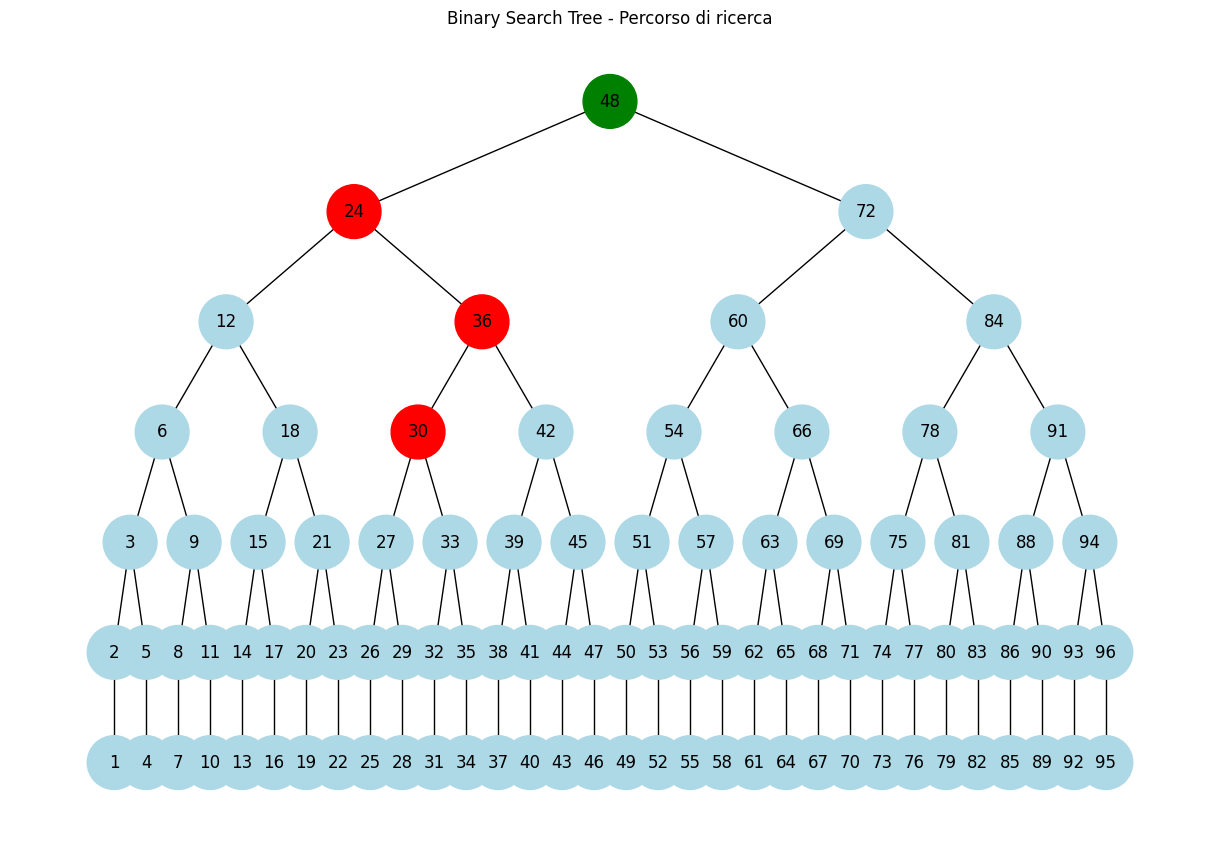

In [81]:
conn = sqlite3.connect("biblioteca.db")
visualizza_bst(conn, 30)

In [83]:
# Hash vs B-tree
result, steps = search_hash(95)

print("RISULTATO:", result)
print("PASSAGGI HASH:", steps)

RISULTATO: (95, 'Oathbringer')
PASSAGGI HASH: 10


Percorso ricerca: [48, 72, 84, 91, 94, 96, 95]
Passaggi ricerca: 6


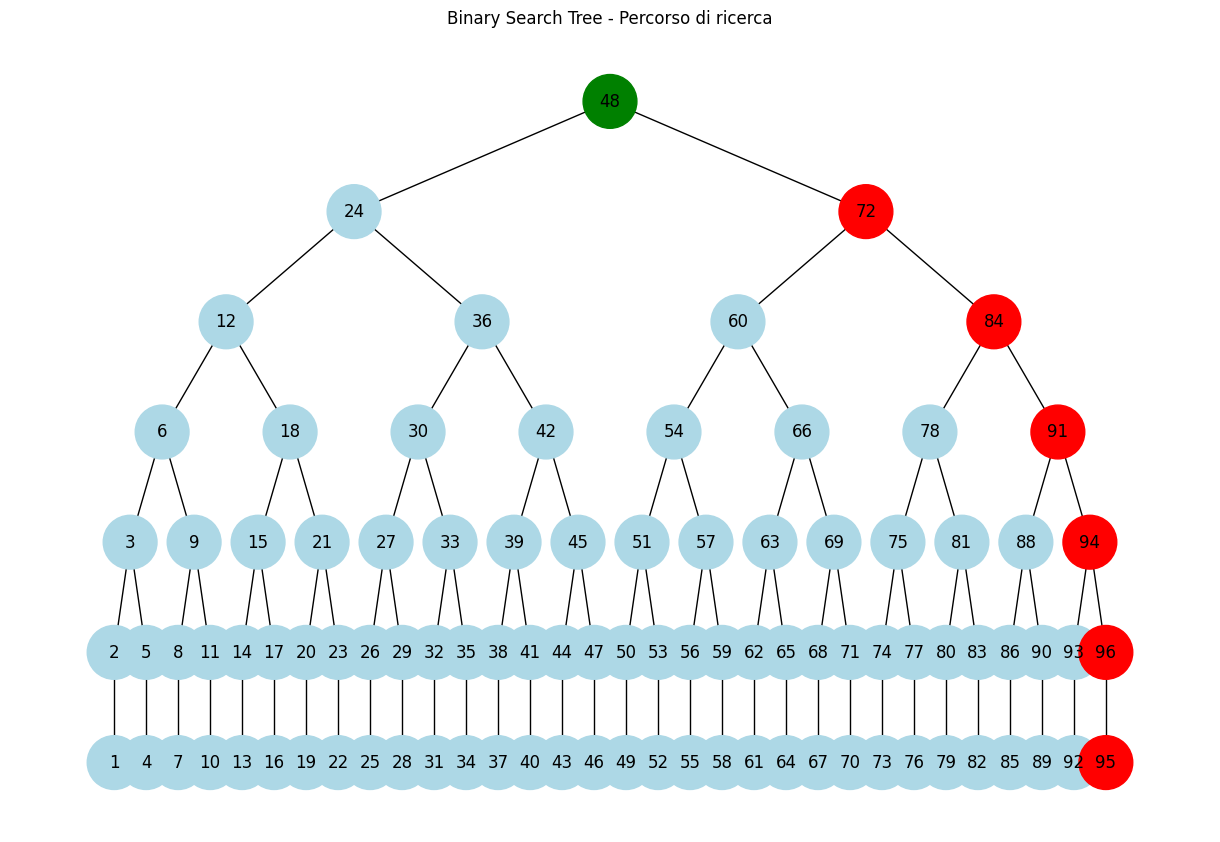

In [84]:
conn = sqlite3.connect("biblioteca.db")
visualizza_bst(conn, 95)